# Scale Numerical Features

### Learning Objectives

We learn to:

1. Explain the need for *Feature Scaling* in layman terms
2. Distinguish between linear and non-linear scaling methods
34. Given a scaled dataset, use `inverse_transform` to show their original values

*Feature Scaling* is an important preprocessing step for many machine learning algorithms:

- to correctly calculate distance (in distance-based models such as **KNeighbors**)
- to correctly do dimensionality reduction algorithms like **PCA**
- to speed up convergence time (in **LogisticRegression** and **SGD**)
- to find a better fit model on **non-linear data** (normalization)

For illustrations, see: [Importance of Feature Scaling | Scikit-learn Docs](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html).

**Feature scaling** puts variables that live on different scales onto a comparable scale.

**Example:** number of rooms might range from 1 to 10, while house area might range from 100 to 1000 square meters.

- We want the model to treat 10 rooms as "large" and 1000 sq m as "large" in their respective contexts, and similarly to treat 1 room and 100 sq m as "small."
- We also do not want the model to effectively ignore the 1–10 range because those numbers are tiny compared to 100–1000.

## Types of Scaling

Scaling methods fall into **linear** and **nonlinear** categories.

### A. Linear scaling

These preserve the relative ordering and spacing of values (up to a linear transform).

Two common options:

#### A.1 Min-max scaling (0–1 range)

In the library ([`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)): map values from their original range to a fixed range, usually 0 to 1.

$$x_\text{scaled} = \frac{x - x_\text{min}}{x_\text{max} - x_\text{min}}$$

**Use when:** Data are roughly **uniform** over a bounded range.

#### A.2 Standard (z-score) scaling

In the library ([`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)): center values at zero (subtract the mean) and scale by standard deviation so values are in "standard units."

The z-score $z$ for a value $x$ is:

$$z = \frac{x - \mu}{s}$$

where $\mu$ and $s$ are the mean and standard deviation of the training samples, respectively.

**Use when:** Data are **normally distributed** (or close to it).

![Normal distribution](../assets/normal_distribution.png)

**In practice:** We often ignore the exact distribution and apply standard scaling anyway. Values beyond roughly ±3 standard deviations are typically treated as **outliers** and may be handled separately.

### B. Nonlinear scaling

These change the relative spacing between values. Examples:

#### B.1 Log scaling

Log scaling can turn skewed (non-normal) distributions into a more **symmetric**, approximately normal shape using the natural logarithm:

$$x_\text{normalized} = \ln(x)$$

As illustrated:

![](https://scikit-learn.org/stable/_images/sphx_glr_plot_transformed_target_001.png)

Remember that the log function is the inverse of the exponent function, as shown in the figure:

![](../assets/exponent_vs_log.png)

Source: [What is a Logarithm? MathIsFun](https://www.mathsisfun.com/algebra/exponents-logarithms.html)

Log-scaling is useful for data that follow a **power-law distribution**: a few very large values and many smaller ones.

**Examples:**

- **City populations:** if you rank cities by population, the largest city is often about twice the second, and three times the third (Zipf's law). In the US, New York City (~8.3 million) is roughly twice the size of Los Angeles (~3.8 million).
- **Attention:** a few movies/books get maybe 90% of the attention; the rest 10% is distributed to the vast majority.

See [Transforming the target variable](https://scikit-learn.org/stable/auto_examples/compose/plot_transformed_target.html).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## Scaling methods on an exemplar DataFrame

Below we use one small DataFrame to illustrate **min-max**, **standard (z-score)**, and **log** scaling. The exemplar has columns on different scales (rooms 1–10, area 100–1000) and a skewed column (e.g. view_count) suited to log scaling.

In [2]:
# Exemplar DataFrame: different scales and one skewed column
# Increase number of values using random generation (preserves ranges and skew)
np.random.seed(42)
n = 500
df = pd.DataFrame({
    "rooms": np.random.randint(1, 11, size=n),
    "area_sqm": np.random.normal(200, 80, size=n).round(0),
    "view_count": np.clip(np.random.lognormal(5, 2.5, size=n).astype(int), 10, 50000),  # skewed (power-law-like)
})
df

,rooms,area_sqm,view_count
0,7,304.0,1957
1,4,202.0,10
2,8,255.0,289
3,5,175.0,1372
4,7,226.0,182
...,...,...,...
495,1,128.0,486
496,7,185.0,139
497,7,165.0,1146
498,9,316.0,4795


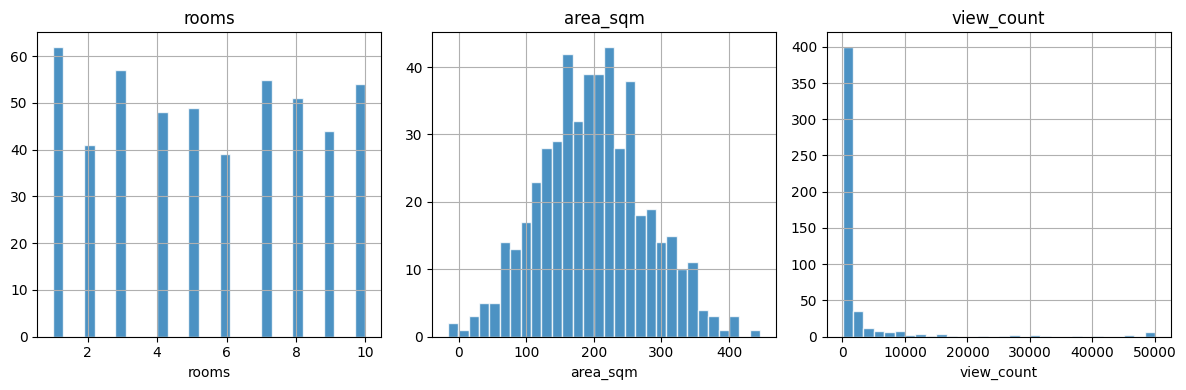

In [3]:
# Histogram of each numerical column
num_cols = df.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    df[col].hist(ax=ax, bins=30, edgecolor="white", alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

### MinMaxScaler (0–1 range)

Each column is scaled to [0, 1] using its min and max. Fit on the data, then transform.

In [14]:
scaler_minmax = MinMaxScaler()
scaled_minmax = scaler_minmax.fit_transform(df[['rooms', 'area_sqm']])
df_scaled = pd.DataFrame(
    scaled_minmax,
    columns=['rooms', 'area_sqm'],
    index=df.index,
)

df_scaled.describe().loc[['min', 'max', 'mean', 'std']]

,rooms,area_sqm
min,0.000000,0.000000
max,1.000000,1.000000
mean,0.492222,0.464823
std,0.326795,0.170411


In [15]:
df_scaled.sample(5)

,rooms,area_sqm
79,0.888889,0.785714
216,0.777778,0.577922
145,0.000000,0.259740
39,0.333333,0.439394
481,1.000000,0.649351


### StandardScaler (z-score)

Each column is centered at 0 and scaled by its standard deviation.

In [9]:
scaler_std = StandardScaler()
scaled_std = scaler_std.fit_transform(df[['area_sqm']])
df_scaled = pd.DataFrame(
    scaled_std,
    columns=['area_sqm'],
    index=df.index,
)

df_scaled.describe()

,area_sqm
count,5.000000e+02
mean,1.172396e-16
std,1.001002e+00
min,-2.730388e+00
25%,-6.992654e-01
50%,-3.153166e-03
75%,6.516374e-01
max,3.143656e+00


Why are there negative values? because in this scale, the zero corresponds to the mean in the original scale.

### Log scaling

Apply natural log to columns that are positive and skewed (e.g. `view_count`). Often we add 1 to avoid log(0): $\ln(x + 1)$.

In [21]:
# Log scale: use np.log1p(x) = log(1 + x) to handle zeros safely
df_log = df.copy()
df_log["view_count_log"] = np.log1p(df["view_count"])
df_log[["view_count", "view_count_log"]].round(2)

,view_count,view_count_log
0,1957,7.58
1,10,2.40
2,289,5.67
3,1372,7.22
4,182,5.21
...,...,...
495,486,6.19
496,139,4.94
497,1146,7.04
498,4795,8.48


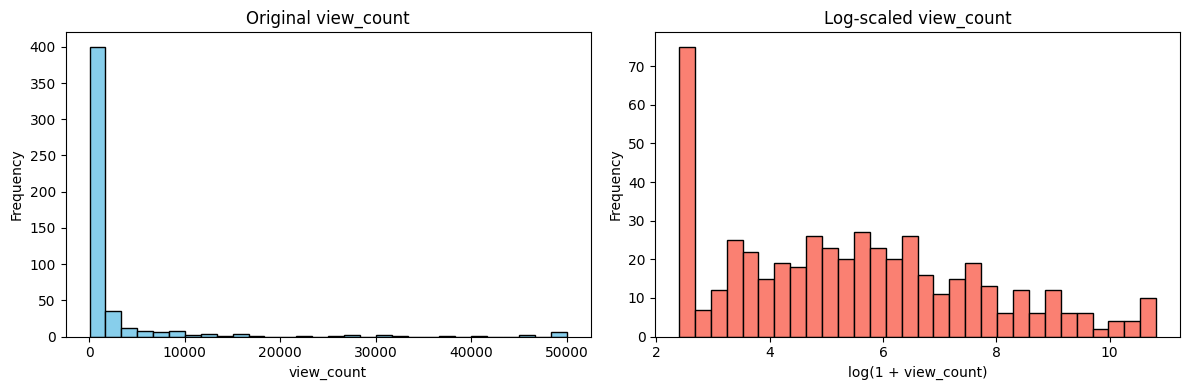

In [22]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(df["view_count"], bins=30, color='skyblue', edgecolor='black')
axs[0].set_title("Original view_count")
axs[0].set_xlabel("view_count")
axs[0].set_ylabel("Frequency")

axs[1].hist(df_log["view_count_log"], bins=30, color='salmon', edgecolor='black')
axs[1].set_title("Log-scaled view_count")
axs[1].set_xlabel("log(1 + view_count)")
axs[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()